# ATM Fraud Detection using Machine Learning

Dataset enriched using:
- Geo Scores
- Instance Scores
- Lambda Weights

Models Compared
1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Support Vector Machine (SVM)
4. Random Forest
   
Goal:
Predict fraudulent ATM transactions.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

## Data Loading and Feature Integration

In [4]:
#Load Files
train = pd.read_csv("data/train.csv")

geo = pd.read_csv("data/Geo_scores.csv")

instance = pd.read_csv("data/instance_scores.csv")

lambda_wt = pd.read_csv("data/Lambda_wts.csv")

qset = pd.read_csv("data/Qset_tats.csv")

test = pd.read_csv("data/test_share.csv")

In [5]:
geo = geo.groupby('id', as_index=False).mean()

instance = instance.groupby('id', as_index=False).mean()

qset = qset.groupby('id', as_index=False).mean()

In [6]:
print(geo.shape)
print(instance.shape)
print(qset.shape)

(284807, 2)
(284807, 2)
(284807, 2)


In [7]:
#Merge Features
train = train.merge(
    geo,
    on='id',
    how='left'
)

train = train.merge(
    instance,
    on='id',
    how='left'
)

train = train.merge(
    qset,
    on='id',
    how='left'
)

train = train.merge(
    lambda_wt,
    on='Group',
    how='left'
)

In [8]:
#Dataset Shape
print(train.shape)
train.head()

(227845, 32)


,id,Group,Per1,Per2,Per3,Per4,Per5,Per6,Per7,Per8,...,Cred3,Cred4,Cred5,Cred6,Normalised_FNT,Target,geo_score,instance_scores,qsets_normalized_tat,lambda_wt
0,112751,Grp169,1.070000,0.580000,0.480000,0.766667,1.233333,1.993333,0.340000,1.010000,...,0.933333,0.603333,0.686667,0.673333,-245.7500,0,0.275,-0.06,-0.700000,-0.13
1,18495,Grp161,0.473333,1.206667,0.883333,1.430000,0.726667,0.626667,0.810000,0.783333,...,0.560000,0.670000,0.553333,0.653333,-248.0000,0,-0.250,0.52,0.140000,0.66
2,23915,Grp261,1.130000,0.143333,0.946667,0.123333,0.080000,0.836667,0.056667,0.756667,...,0.763333,0.670000,0.686667,0.673333,-233.1250,0,-0.950,1.56,-0.430000,-0.51
3,50806,Grp198,0.636667,1.090000,0.750000,0.940000,0.743333,0.346667,0.956667,0.633333,...,0.423333,0.520000,0.846667,0.760000,-249.7775,0,0.490,0.70,-0.516667,0.72
4,184244,Grp228,0.560000,1.013333,0.593333,0.416667,0.773333,0.460000,0.853333,0.796667,...,0.520000,0.716667,0.706667,0.673333,-247.5775,0,0.850,-0.47,-0.630000,0.60


In [9]:
#Missing Values
train.isnull().sum()

id                      0
Group                   0
Per1                    0
Per2                    0
Per3                    0
Per4                    0
Per5                    0
Per6                    0
Per7                    0
Per8                    0
Per9                    0
Dem1                    0
Dem2                    0
Dem3                    0
Dem4                    0
Dem5                    0
Dem6                    0
Dem7                    0
Dem8                    0
Dem9                    0
Cred1                   0
Cred2                   0
Cred3                   0
Cred4                   0
Cred5                   0
Cred6                   0
Normalised_FNT          0
Target                  0
geo_score               0
instance_scores         0
qsets_normalized_tat    0
lambda_wt               0
dtype: int64

In [10]:
#Fill Missing Values
for col in train.columns:
    if train[col].dtype != 'object':
        train[col].fillna(
            train[col].median(),
            inplace=True)

## Exploratory Data Analysis (EDA)

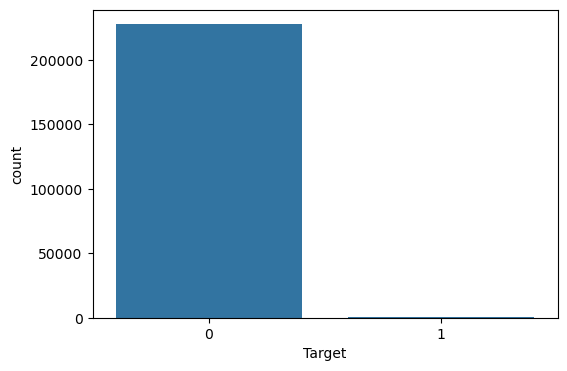

In [11]:
# Target Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Target', data=train)
plt.show()

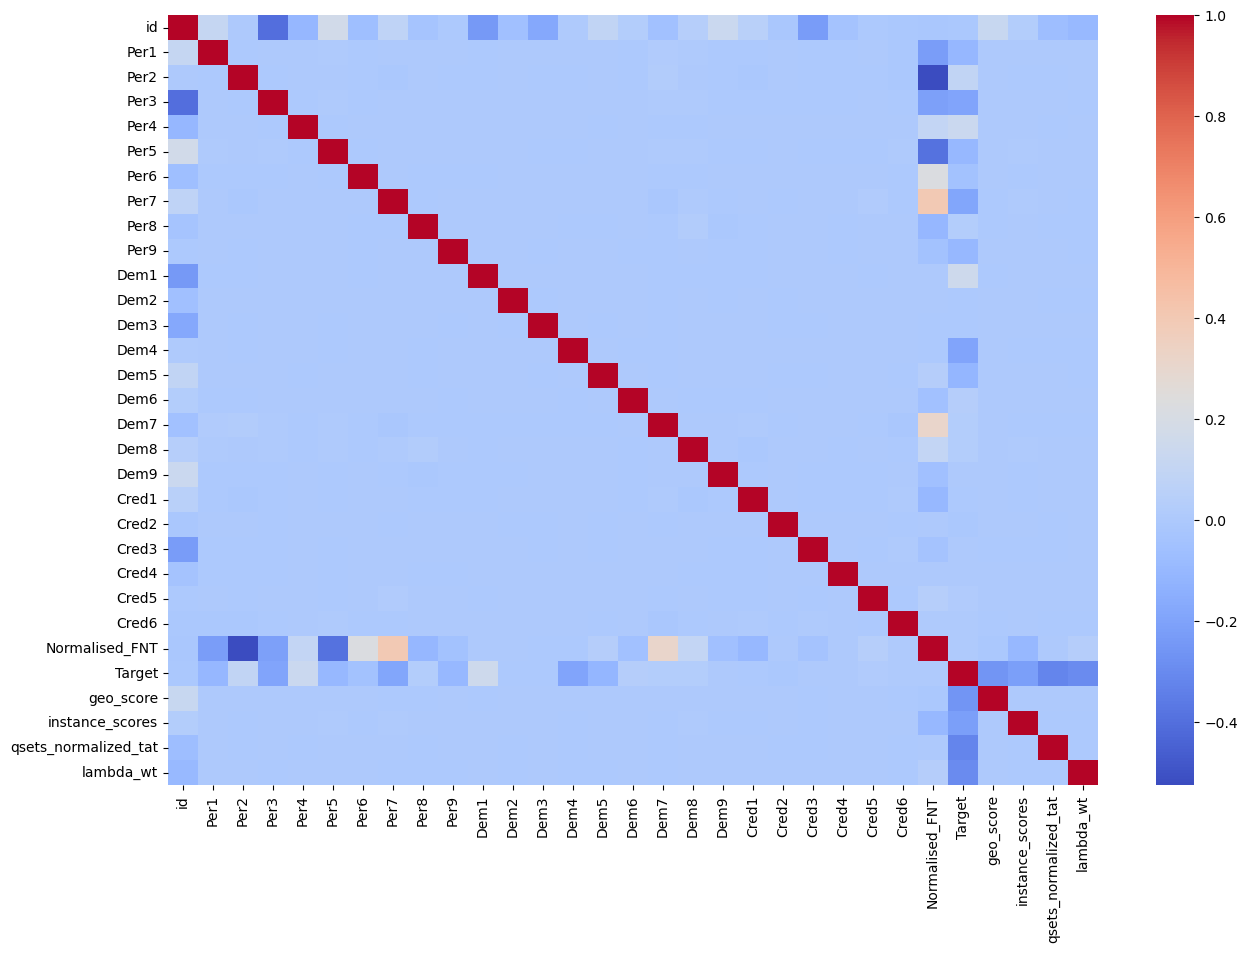

In [12]:
# Correlation Heatmap
plt.figure(figsize=(15,10))
sns.heatmap(train.corr(numeric_only=True), cmap='coolwarm')
plt.show()

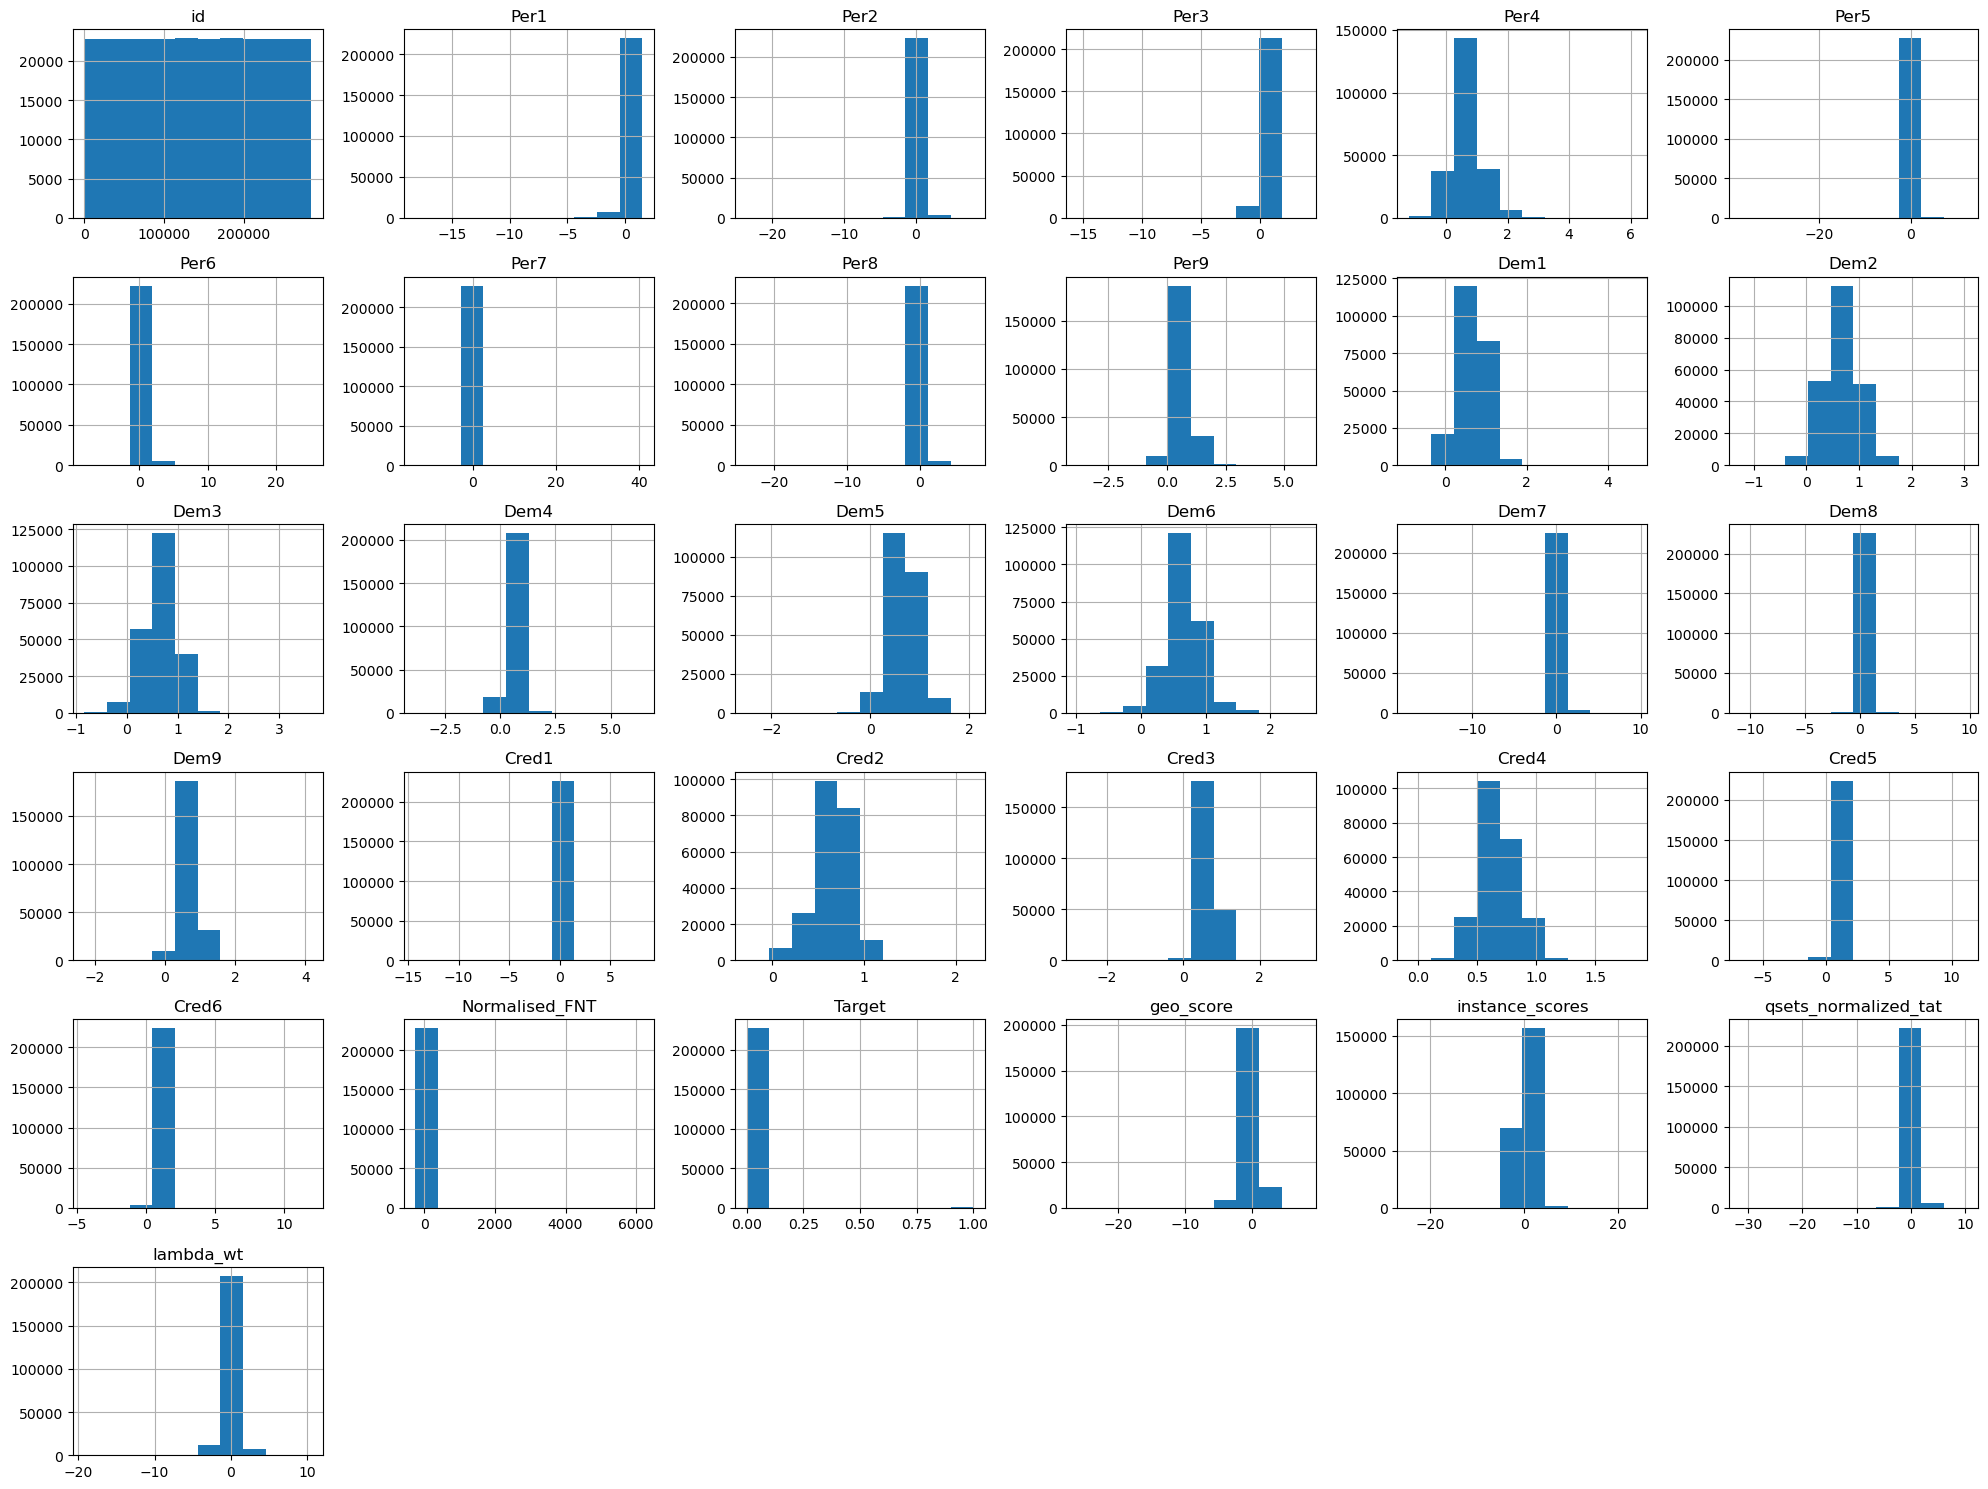

In [13]:
# Feature Histograms
train.hist(figsize=(20,15))
plt.tight_layout()
plt.show()

In [14]:
print(train.shape)
print(train.head())

(227845, 32)
       id   Group      Per1      Per2      Per3      Per4      Per5      Per6  \
0  112751  Grp169  1.070000  0.580000  0.480000  0.766667  1.233333  1.993333   
1   18495  Grp161  0.473333  1.206667  0.883333  1.430000  0.726667  0.626667   
2   23915  Grp261  1.130000  0.143333  0.946667  0.123333  0.080000  0.836667   
3   50806  Grp198  0.636667  1.090000  0.750000  0.940000  0.743333  0.346667   
4  184244  Grp228  0.560000  1.013333  0.593333  0.416667  0.773333  0.460000   

       Per7      Per8  ...     Cred3     Cred4     Cred5     Cred6  \
0  0.340000  1.010000  ...  0.933333  0.603333  0.686667  0.673333   
1  0.810000  0.783333  ...  0.560000  0.670000  0.553333  0.653333   
2  0.056667  0.756667  ...  0.763333  0.670000  0.686667  0.673333   
3  0.956667  0.633333  ...  0.423333  0.520000  0.846667  0.760000   
4  0.853333  0.796667  ...  0.520000  0.716667  0.706667  0.673333   

   Normalised_FNT  Target  geo_score  instance_scores  qsets_normalized_tat  \


## Data Preprocessing

In [15]:
# Encode Group
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train['Group'] = le.fit_transform(train['Group'])
train.head()

,id,Group,Per1,Per2,Per3,Per4,Per5,Per6,Per7,Per8,...,Cred3,Cred4,Cred5,Cred6,Normalised_FNT,Target,geo_score,instance_scores,qsets_normalized_tat,lambda_wt
0,112751,420,1.070000,0.580000,0.480000,0.766667,1.233333,1.993333,0.340000,1.010000,...,0.933333,0.603333,0.686667,0.673333,-245.7500,0,0.275,-0.06,-0.700000,-0.13
1,18495,413,0.473333,1.206667,0.883333,1.430000,0.726667,0.626667,0.810000,0.783333,...,0.560000,0.670000,0.553333,0.653333,-248.0000,0,-0.250,0.52,0.140000,0.66
2,23915,523,1.130000,0.143333,0.946667,0.123333,0.080000,0.836667,0.056667,0.756667,...,0.763333,0.670000,0.686667,0.673333,-233.1250,0,-0.950,1.56,-0.430000,-0.51
3,50806,452,0.636667,1.090000,0.750000,0.940000,0.743333,0.346667,0.956667,0.633333,...,0.423333,0.520000,0.846667,0.760000,-249.7775,0,0.490,0.70,-0.516667,0.72
4,184244,486,0.560000,1.013333,0.593333,0.416667,0.773333,0.460000,0.853333,0.796667,...,0.520000,0.716667,0.706667,0.673333,-247.5775,0,0.850,-0.47,-0.630000,0.60


In [16]:
# Split X and y
X = train.drop(['Target','id'], axis=1)

y = train['Target']

In [17]:
# Train Test Split
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
# Handle Imbalance Using SMOTE
smote = SMOTE(random_state=42)

X_train,y_train = smote.fit_resample(X_train, y_train)

In [19]:
# Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

## Model 1: Logistic Regression

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Accuracy:",lr_acc)

Accuracy: 0.9835633873905506


## Model 2: KNN

In [21]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train,y_train)

knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("Accuracy:",knn_acc)

Accuracy: 0.997586078254954


## Model 3: XGBoost

In [22]:
!pip install xgboost

In [23]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

print("Accuracy:", xgb_acc)

Accuracy: 0.999297768219623


## Model 4: Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Accuracy:",rf_acc)

Accuracy: 0.9994294366784436


## Model Comparison

In [27]:
results = pd.DataFrame({

    'Model':[
        'Logistic Regression',
        'KNN',
        'XGBoost',
        'Random Forest'
    ],

    'Accuracy':[
        lr_acc,
        knn_acc,
        xgb_acc,
        rf_acc
    ]
})

results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
3,Random Forest,0.999429
2,XGBoost,0.999298
1,KNN,0.997586
0,Logistic Regression,0.983563


## Classification Reports

In [28]:
# Random Forest
from sklearn.metrics import classification_report

print("Random Forest Report")
print(classification_report(y_test, rf_pred))

Random Forest Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45490
           1       0.87      0.78      0.83        79

    accuracy                           1.00     45569
   macro avg       0.94      0.89      0.91     45569
weighted avg       1.00      1.00      1.00     45569



In [29]:
print("XGBoost Report")
print(classification_report(y_test, xgb_pred))

XGBoost Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45490
           1       0.79      0.81      0.80        79

    accuracy                           1.00     45569
   macro avg       0.89      0.90      0.90     45569
weighted avg       1.00      1.00      1.00     45569



## Confusion Matrix (Random Forest)

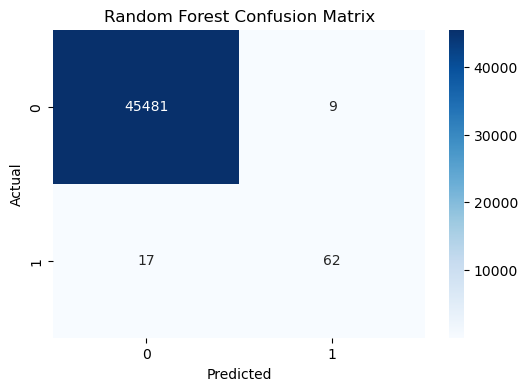

In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## ROC Curve Comparison

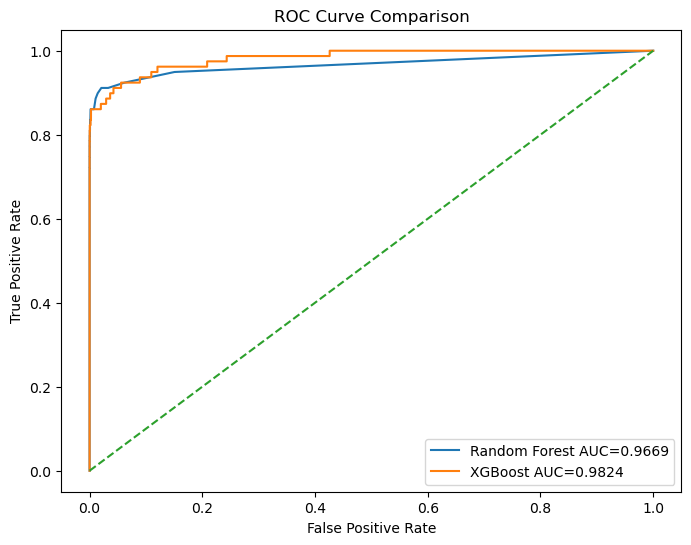

In [31]:
from sklearn.metrics import roc_curve, roc_auc_score

rf_prob = rf.predict_proba(X_test)[:,1]
xgb_prob = xgb.predict_proba(X_test)[:,1]

rf_auc = roc_auc_score(y_test, rf_prob)
xgb_auc = roc_auc_score(y_test, xgb_prob)

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

plt.figure(figsize=(8,6))

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f'Random Forest AUC={rf_auc:.4f}'
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f'XGBoost AUC={xgb_auc:.4f}'
)

plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve Comparison')

plt.legend()

plt.show()

## Feature Importance (Random Forest)

In [32]:
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance':
    rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(20)

,Feature,Importance
29,lambda_wt,0.178391
27,instance_scores,0.143403
4,Per4,0.105063
28,qsets_normalized_tat,0.092579
3,Per3,0.086119
26,geo_score,0.079631
10,Dem1,0.065035
13,Dem4,0.045601
7,Per7,0.028447
14,Dem5,0.020598


## Visualization

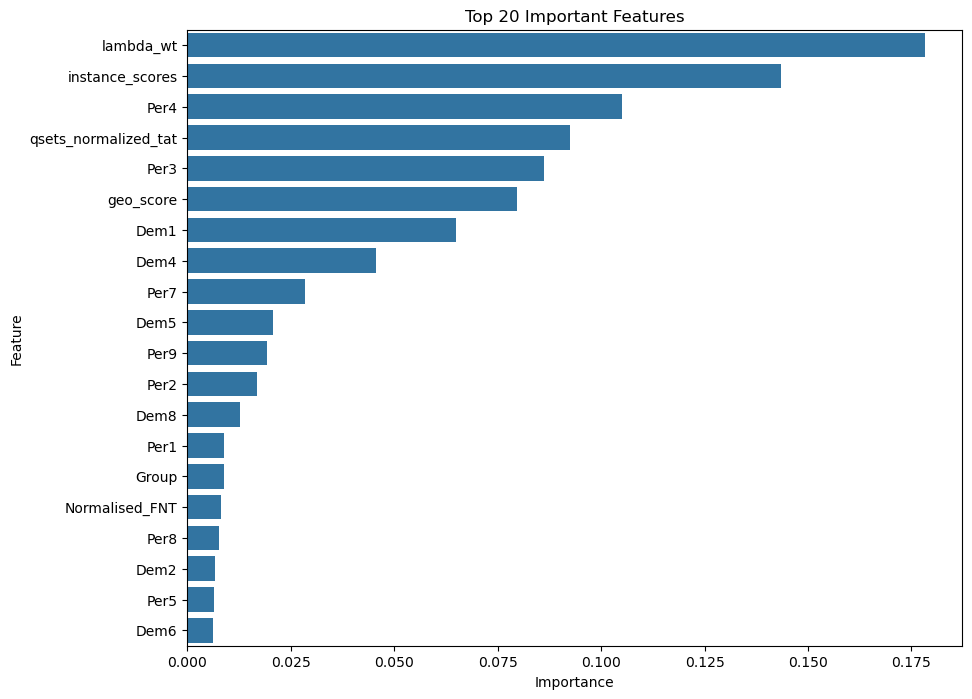

In [33]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(20),
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 20 Important Features'
)

plt.show()

## Save Best Model

In [34]:
import joblib

joblib.dump(
    rf,
    "atm_fraud_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully
